In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from reflectivity2 import plot_measurement, compare_measurements, avg_reflectivity

%matplotlib widget

In [2]:
def series_plot(measurements, ref, dir='', plot_all=False):
    files = [glob.glob(dir+str(measurement)+"*.csv")[0] for measurement in measurements]
    if plot_all:
        for file in files:
            plot_measurement(file, ref, wl_window=(550, 1050), savgol_params=(51, 3))
    return compare_measurements(files, ref, wl_window=(550, 1050), savgol_params=(51, 3))

In [3]:
calib_ref = np.loadtxt("ALREF 21017.rrr", delimiter=',', skiprows=1, unpack=True)
t_ref_5 = np.loadtxt("Filmetrics_Al_5nmoxide.txt", skiprows=1, unpack=True)
t_ref_10 = np.loadtxt("Filmetrics_Al_10nmoxide.txt", skiprows=1, unpack=True)

# Misure ALREF 21017

## Luce ambientale accesa, 200 ms int. time, media di 5 misure

c:\Users\chioettop\My Drive\Ariel Mirrors\M1 Reflectivity Measurement Setup\srms\reflectivity2.py:80: RuntimeWarning: divide by zero encountered in divide
  rft = (reflected - dark2) / ((direct1 - dark1 + direct2 - dark3) / 2)


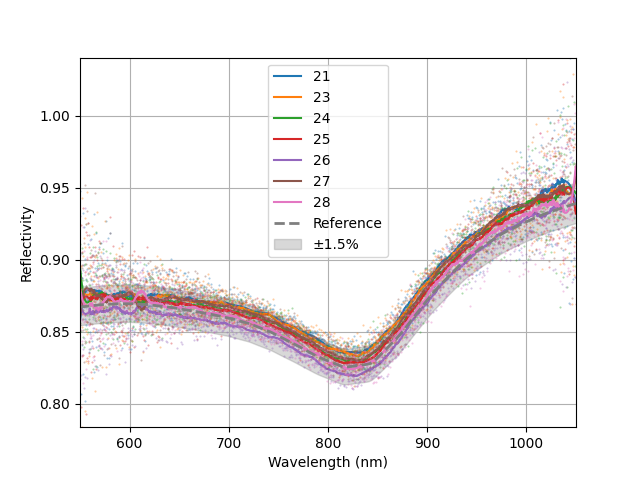

In [4]:
measurements = [21, 23, 24, 25, 26, 27, 28]
fig = series_plot(measurements, calib_ref, dir="../Measurements/")

## Ambient light off

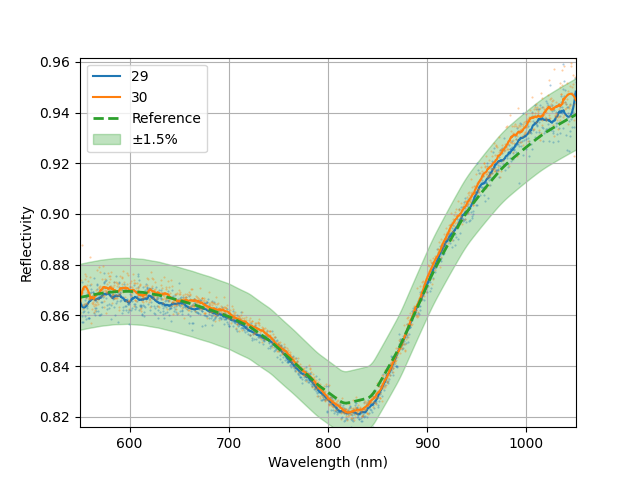

In [5]:
measurements = [29, 30]
fig = series_plot(measurements, calib_ref, dir="../Measurements/")

# 50 mm Mirror

c:\Users\chioettop\My Drive\Ariel Mirrors\M1 Reflectivity Measurement Setup\srms\reflectivity2.py:80: RuntimeWarning: invalid value encountered in divide
  rft = (reflected - dark2) / ((direct1 - dark1 + direct2 - dark3) / 2)


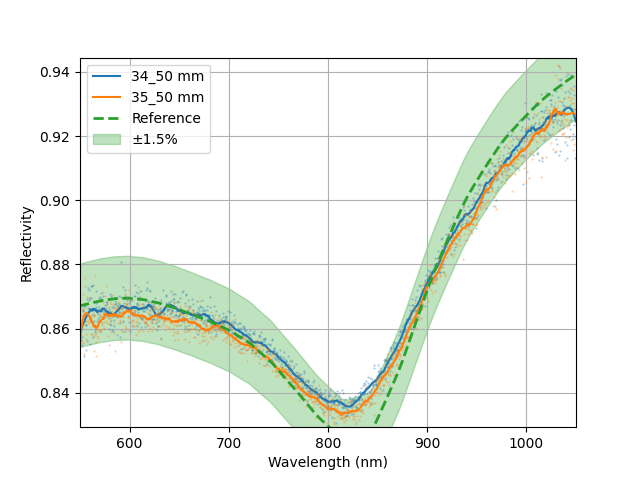

In [6]:
measurements = [34, 35]
fig = series_plot(measurements, calib_ref, dir="../Measurements/")

## Comparison with Filmetrics data
The parameters are bogus: roughness is certainly less than 10 nm RMS and Al2O3 thickness < 5 nm. 
The explanation is that Al6061 is probably less reflective than pure Al, but I can't find optical constants for it.

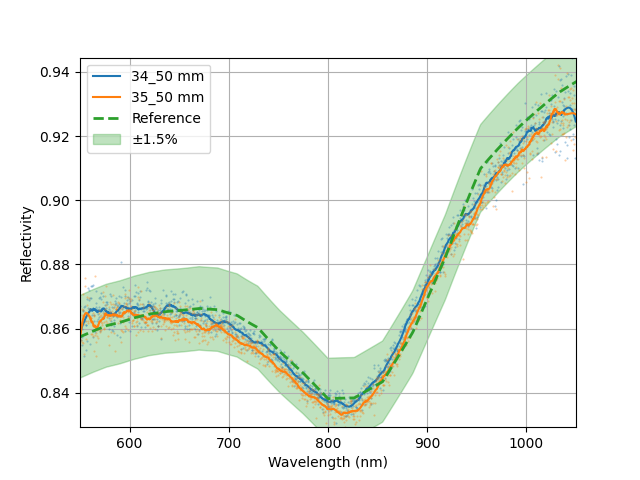

In [7]:
path = "../Measurements/"
files = [glob.glob(path+str(measurement)+"*.csv")[0] for measurement in measurements]
r = 11 #  nm RMS roughness
t_ref_r = t_ref_10.copy()
t_ref_r[1] *= np.exp(-(4*np.pi*r/t_ref_r[0])**2)
fig = compare_measurements(files, t_ref_r, wl_window=(550, 1050), savgol_params=(51, 3))

# 150 mm mirror

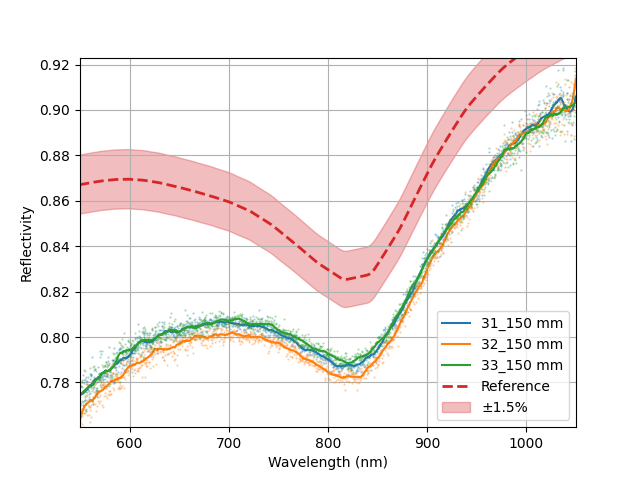

In [8]:
measurements = [31, 32, 33]
fig = series_plot(measurements, calib_ref, dir="../Measurements/")

## Relative reflectivity vs. 50 mm mirror 
Supposedly due to surface error features

Fitted RMS roughness: 14.7330 nm


c:\Users\chioettop\My Drive\Ariel Mirrors\M1 Reflectivity Measurement Setup\srms\reflectivity2.py:128: RuntimeWarning: divide by zero encountered in divide
  rft = (reflected - dark2) / ((direct1 - dark1 + direct2 - dark3) / 2)
c:\Users\chioettop\My Drive\Ariel Mirrors\M1 Reflectivity Measurement Setup\srms\reflectivity2.py:128: RuntimeWarning: invalid value encountered in divide
  rft = (reflected - dark2) / ((direct1 - dark1 + direct2 - dark3) / 2)


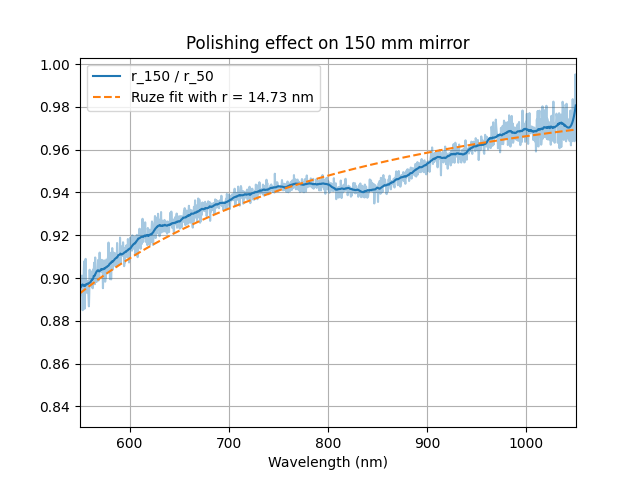

In [9]:
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

measurements = [31, 32, 33]  # 150 mm mirror
path = "../Measurements/"
files = [glob.glob(path+str(measurement)+"*.csv")[0] for measurement in measurements]
wl, r_150 = avg_reflectivity(files)

measurements = [34, 35]  # 50 mm mirror
files = [glob.glob(path+str(measurement)+"*.csv")[0] for measurement in measurements]
wl, r_50 = avg_reflectivity(files)

i_range = np.where((wl >= 500) & (wl <= 1050))
ratio = r_150[i_range] / r_50[i_range]
wl = wl[i_range]

# Fit Ruze model to the ratio of reflectivities
def ruze(x, r):
    return np.exp(-(4*np.pi*r/x)**2)

# Fit the curve
y = savgol_filter(ratio, 51, 3)
r, covariance = curve_fit(ruze, wl, ratio, p0=0.5)  # Initial guesses for r

print(f"Fitted RMS roughness: {r[0]:.4f} nm")
# Generate fitted curve
x_fit = wl
y_fit = ruze(x_fit, r)

fig, ax = plt.subplots()
l, = ax.plot(wl, ratio, alpha=.4)
ax.plot(wl, savgol_filter(ratio, 51, 3), color=l.get_color(), label="r_150 / r_50")
ax.plot(x_fit, y_fit, linestyle='--', label="Ruze fit with r = %.2f nm" % r[0])
ax.set_xlim(550, 1050)
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Polishing effect on 150 mm mirror")
ax.legend()
plt.grid()

# Final Setup

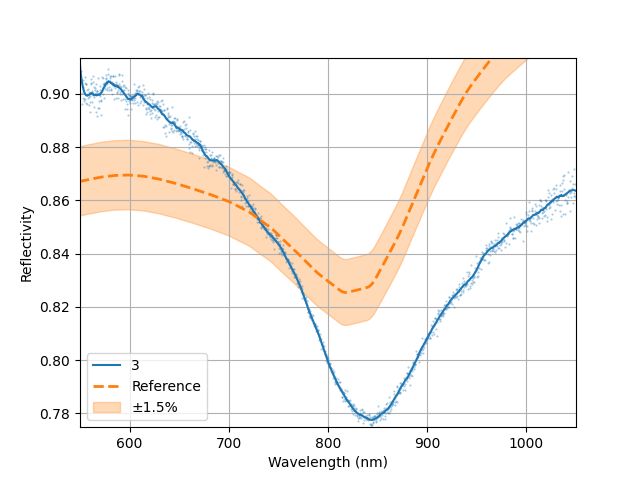

In [ ]:
# Set 3: Edmund mirror with the old fiber. Much better.
measurements = [3]
fig = series_plot(measurements, calib_ref, dir="../Measurements/Final setup/")

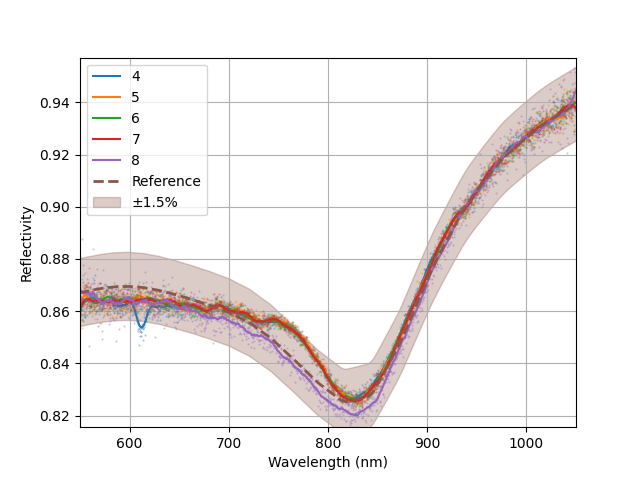

In [ ]:
# Alref-21017 various configurations of ambient light and int. time
measurements = [4, 5, 6, 7, 8]
fig = series_plot(measurements, calib_ref, dir="../Measurements/Final setup/")

Text(0.5, 1.0, 'Alref-21017 - 04/07/2025')

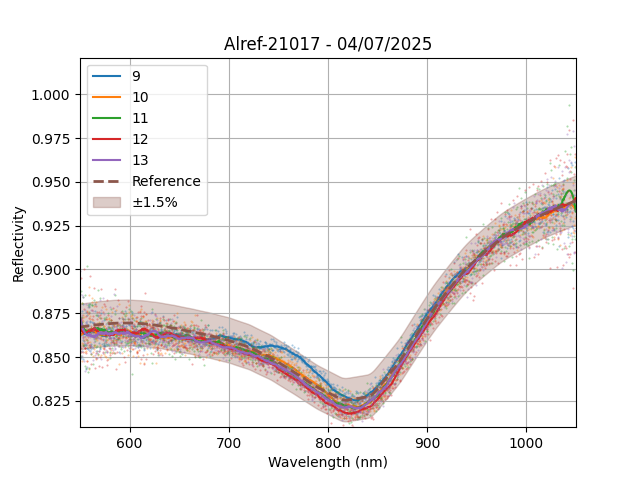

In [6]:
# Alref-21017 various configurations of int. time and sample repositioning
measurements = [9, 10, 11, 12, 13]
fig = series_plot(measurements, calib_ref, dir="../Measurements/Final setup/")
fig.gca().set_title("Alref-21017 - 04/07/2025")

c:\Users\chioettop\Il mio Drive\Ariel Mirrors\M1 Reflectivity Measurement Setup\srms\reflectivity2.py:103: RuntimeWarning: divide by zero encountered in divide
  rft = (reflected) / ((direct1 + direct2) / 2)


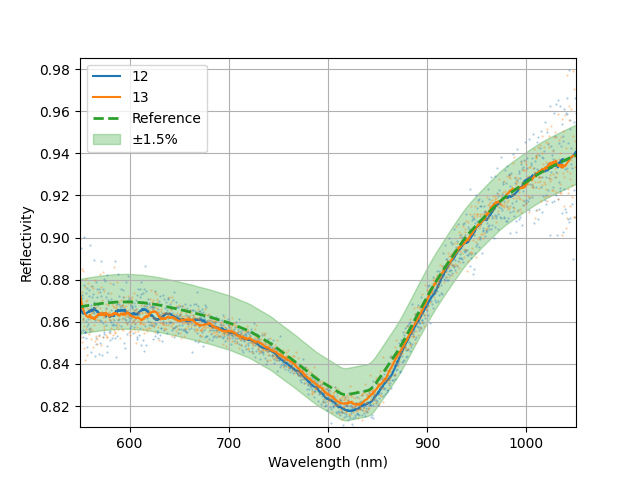

In [5]:
# Alref-21017 sample repositioning (repeatability)
measurements = [12, 13]
fig = series_plot(measurements, calib_ref, dir="../Measurements/Final setup/")

## 50 mm mirror

Text(0.5, 1.0, 'MDL 50 mm Al mirror - 04/07/2025')

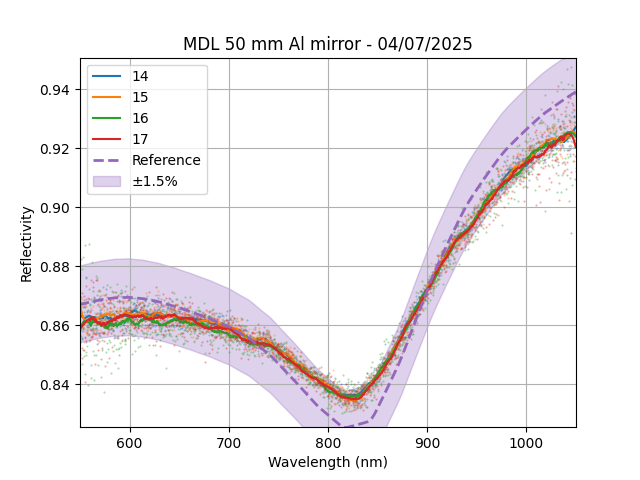

In [14]:
measurements = [14, 15, 16, 17]
fig = series_plot(measurements, calib_ref, dir="../Measurements/Final setup/")
fig.gca().set_title("MDL 50 mm Al mirror - 04/07/2025")

## 150 mm mirror

Text(0.5, 1.0, 'MDL 150 mm Al mirror - 04/07/2025')

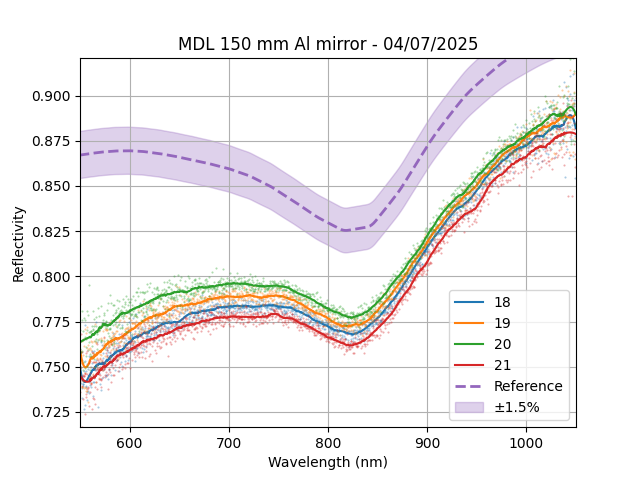

In [15]:
# measurements at different location of the mirror
measurements = [18, 19, 20, 21]
fig = series_plot(measurements, calib_ref, dir="../Measurements/Final setup/")
fig.gca().set_title("MDL 150 mm Al mirror - 04/07/2025")

Text(0.5, 1.0, 'MDL 150 mm Al mirror - 04/07/2025\nBeam diameter test')

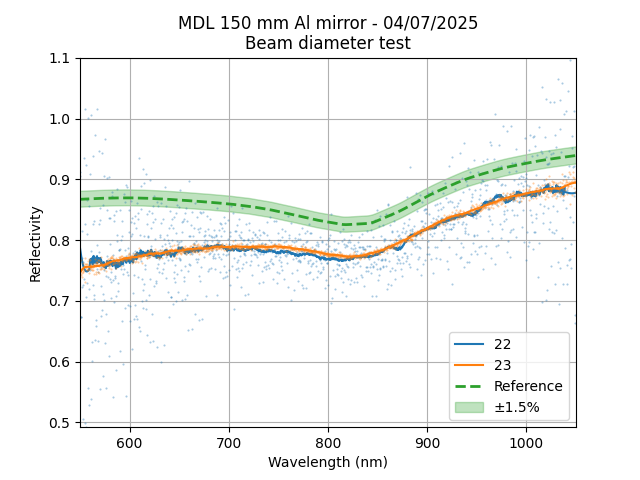

In [16]:
measurements = [22, 23]
fig = series_plot(measurements, calib_ref, dir="../Measurements/Final setup/")
fig.gca().set_title("MDL 150 mm Al mirror - 04/07/2025\nBeam diameter test")

## Thorlabs CM 508 mirror, f = 1000 mm


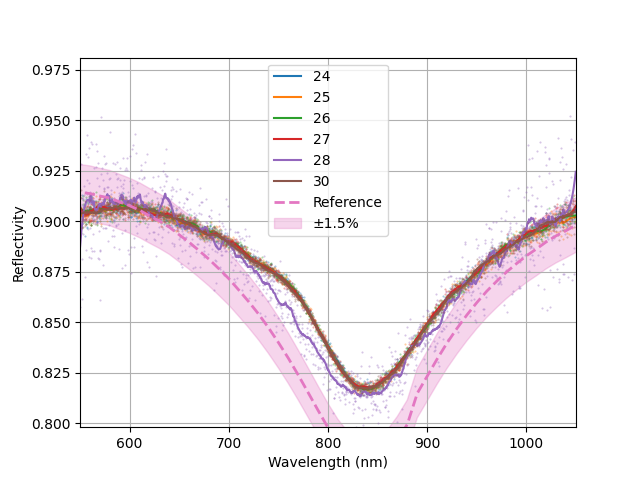

In [17]:
cm508_ref = np.loadtxt("CM508G01.csv", skiprows=1, delimiter=';', unpack=True)
cm508_ref[0] *= 1000  # Convert wavelength to nm
cm508_ref[1] /= 100  # Convert reflectivity to percentage

# Measurement #30 done in the finel upside down configuration
measurements = [24, 25, 26, 27, 28, 30]
fig = series_plot(measurements, cm508_ref, dir="../Measurements/Final setup/")

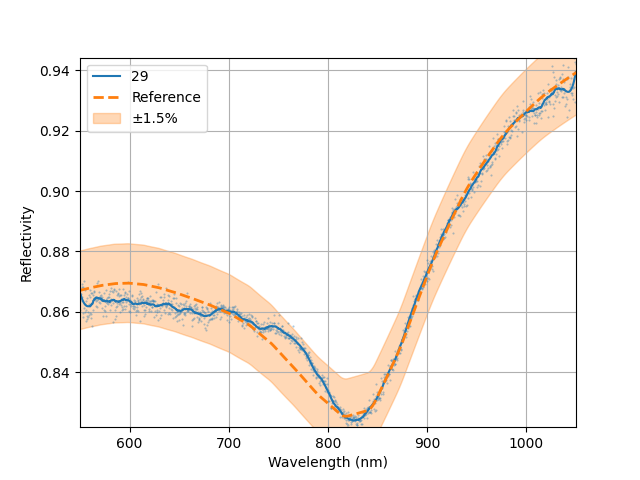

In [18]:
# Alref-21017 measurement with new software
measurements = [29]
fig = series_plot(measurements, calib_ref, dir="../Measurements/Final setup/")

c:\Users\chioettop\My Drive\Ariel Mirrors\M1 Reflectivity Measurement Setup\srms\reflectivity2.py:80: RuntimeWarning: divide by zero encountered in divide
  rft = (reflected - dark2) / ((direct1 - dark1 + direct2 - dark3) / 2)


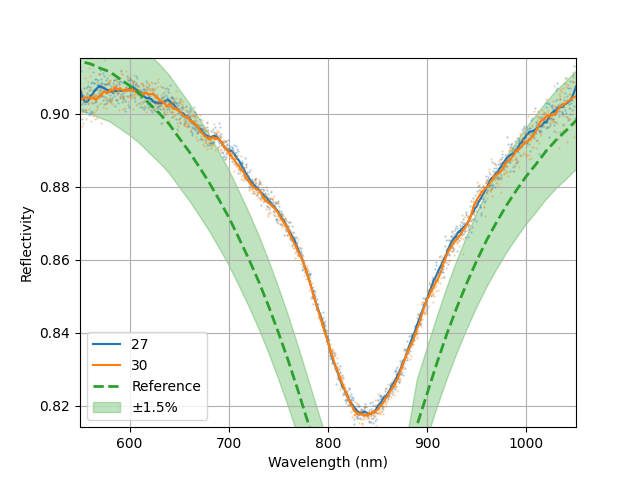

In [21]:
# Set 30: CM508 first measurement in final Ariel M1 configuration
measurements = [27, 30]
fig = series_plot(measurements, cm508_ref, dir="../Measurements/Final setup/")

# 150 mirror vs 50 mirror - Ruze fit (final setup)

Fitted RMS roughness: 16.7446 nm


c:\Users\chioettop\My Drive\Ariel Mirrors\M1 Reflectivity Measurement Setup\srms\reflectivity2.py:128: RuntimeWarning: divide by zero encountered in divide
  rft = (reflected - dark2) / ((direct1 - dark1 + direct2 - dark3) / 2)


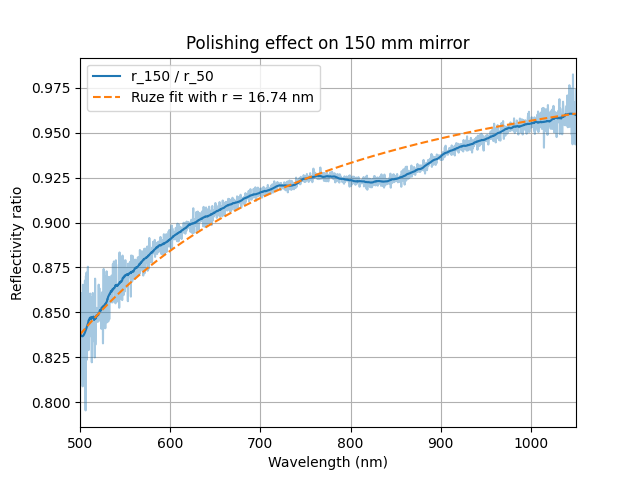

In [26]:
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

measurements = [18, 19, 20, 21, 23]  # 150 mm mirror
path = "../Measurements/Final setup/"
files = [glob.glob(path+str(measurement)+"*.csv")[0] for measurement in measurements]
wl, r_150 = avg_reflectivity(files)

measurements = [14, 15, 16, 17]  # 50 mm mirror
files = [glob.glob(path+str(measurement)+"*.csv")[0] for measurement in measurements]
wl, r_50 = avg_reflectivity(files)

i_range = np.where((wl >= 500) & (wl <= 1050))
ratio = r_150[i_range] / r_50[i_range]
wl = wl[i_range]

# Fit Ruze model to the ratio of reflectivities
def ruze(wl, s):
    return np.exp(-(4*np.pi*s/wl)**2)

# Fit the curve
y = savgol_filter(ratio, 51, 3)
r, covariance = curve_fit(ruze, wl, y, p0=0.5)  # Initial guesses for r

print(f"Fitted RMS roughness: {r[0]:.4f} nm")
# Generate fitted curve
x_fit = wl
y_fit = ruze(x_fit, r)

fig, ax = plt.subplots()
l, = ax.plot(wl, ratio, alpha=.4)
ax.plot(wl, y, color=l.get_color(), label="r_150 / r_50")
ax.plot(x_fit, y_fit, linestyle='--', label="Ruze fit with r = %.2f nm" % r[0])
ax.set_xlim(500, 1050)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectivity ratio")
ax.set_title("Polishing effect on 150 mm mirror")
ax.legend()
plt.grid()

# Test before MDL

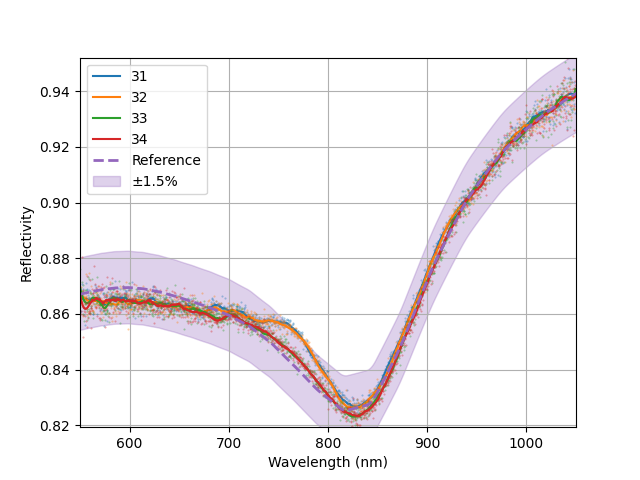

In [9]:
# Set 31: Alref-21017
measurements = [31, 32, 33, 34]
fig = series_plot(measurements, calib_ref, dir="../Measurements/Final setup/")